In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "https://raw.githubusercontent.com/RAlwean/Renaldi-Alwean-Saputra_2411532003_ML2526/refs/heads/main/Praktikum4/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

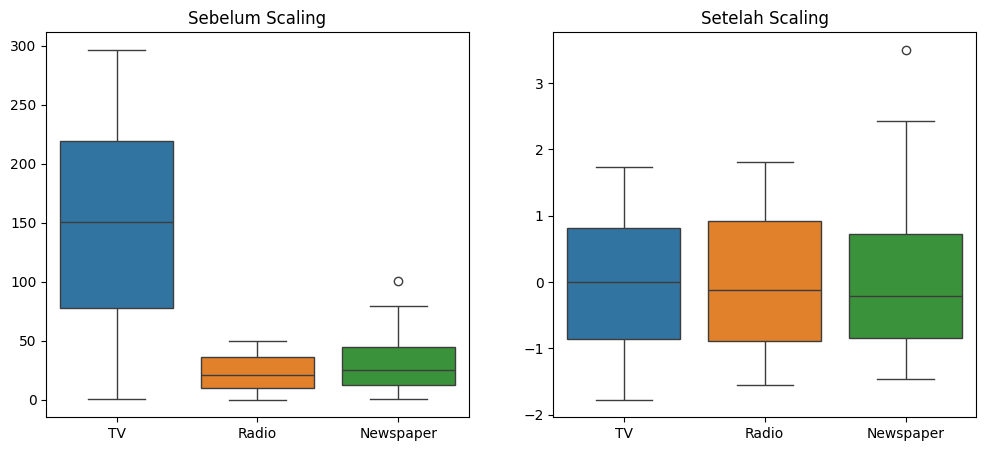

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=X_train[['TV', 'Radio', 'Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV', 'Radio', 'Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [6]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [7]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


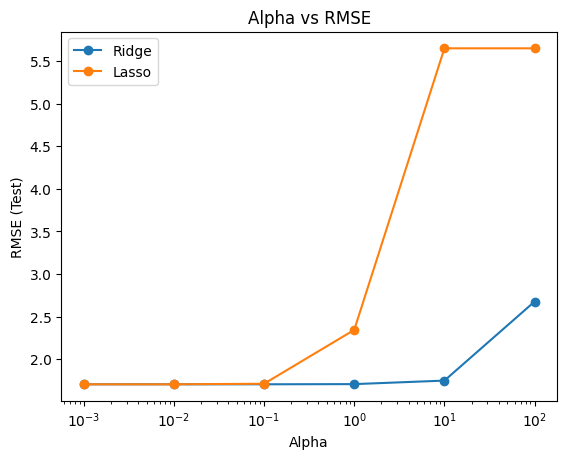

In [8]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

In [9]:
new_alphas = [0.005, 0.05, 0.5, 5, 50]
ridge_coeffs = []
lasso_coeffs = []

print("Eksperimen Tambahan (RMSE Test):")
for a in new_alphas:
    r_model = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l_model = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_coeffs.append(r_model.coef_)
    lasso_coeffs.append(l_model.coef_)

    r_rmse = np.sqrt(mean_squared_error(y_test, r_model.predict(X_test_scaled)))
    print(f"Alpha {a}: Ridge RMSE = {r_rmse:.4f}")


Eksperimen Tambahan (RMSE Test):
Alpha 0.005: Ridge RMSE = 1.7052
Alpha 0.05: Ridge RMSE = 1.7053
Alpha 0.5: Ridge RMSE = 1.7063
Alpha 5: Ridge RMSE = 1.7214
Alpha 50: Ridge RMSE = 2.1490


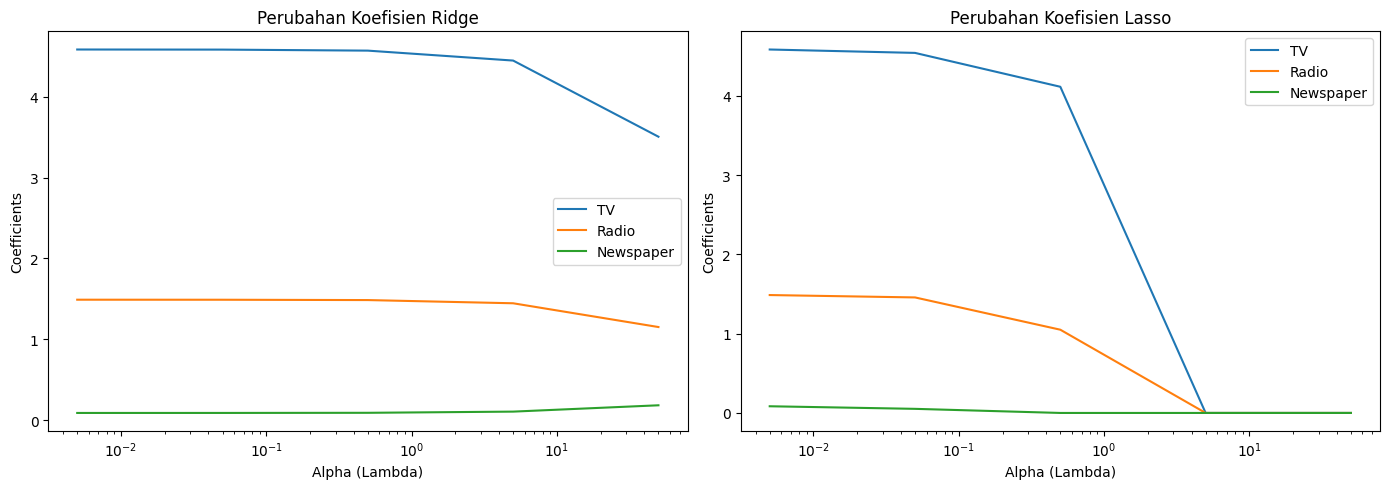

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(new_alphas, ridge_coeffs)
plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('Coefficients')
plt.title('Perubahan Koefisien Ridge')
plt.legend(X.columns)

plt.subplot(1, 2, 2)
plt.plot(new_alphas, lasso_coeffs)
plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('Coefficients')
plt.title('Perubahan Koefisien Lasso')
plt.legend(X.columns)

plt.tight_layout()
plt.show()